In [1]:
import numpy as np
import matplotlib.pyplot as plt

from rkhs_glm_scaled import RKHSGLM_Scaled, sigmoid
from pseudo_label_experiment_general import KGLM_covariate_shift, mean

In [2]:
# User-tunable parameters
beta = 1.3
seed = 29
n = 4000
lbd_min = 1e-5
lbd_max = 1e-3
lbd_tilde = np.log(n) * lbd_min  # Regularization for imputation model; None = use lbd_min
n_lambda = None  # Set to e.g. 50 for denser grid; None uses beta to determine grid

# Fixed parameters
n_0 = n
B = n ** 0.45
fcn = lambda x: 1.5 * np.cos(2 * np.pi * x)

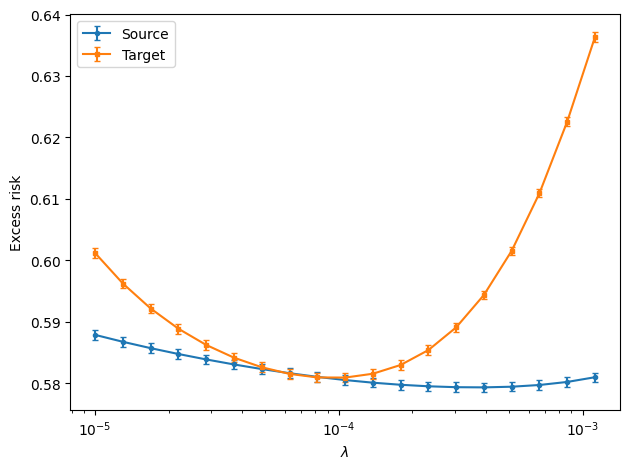

Best lambda (source): 3.94e-04
Best lambda (target): 1.06e-04


In [3]:
# Fit model and evaluate candidates on source and target
test = KGLM_covariate_shift(n, n_0, B, fcn=fcn, family='logistic', kernel='sobolev_intercept', seed=seed)
fit_kw = dict(rho=0.5, beta=beta, lbd_min=lbd_min, lbd_max=lbd_max)
if lbd_tilde is not None:
    fit_kw['lbd_tilde'] = lbd_tilde
if n_lambda is not None:
    fit_kw['n_lambda'] = n_lambda
test.fit(**fit_kw)

list_idx_candidates = list(range(len(test.Lambda)))
N_test = 10000

test.evaluate_candidates(distribution='source', list_idx_candidates=list_idx_candidates, N_test=N_test, seed=seed)
err_source = list(test.err_candidates)
err_source_ste = list(test.err_candidates_ste)

test.evaluate_candidates(distribution='target', list_idx_candidates=list_idx_candidates, N_test=N_test, seed=seed)
err_target = list(test.err_candidates)
err_target_ste = list(test.err_candidates_ste)

lambdas = test.Lambda

# Plot excess risk vs lambda
fig, ax = plt.subplots()
ax.errorbar(lambdas, err_source, yerr=err_source_ste, fmt='o-', label='Source', capsize=2, markersize=3)
ax.errorbar(lambdas, err_target, yerr=err_target_ste, fmt='s-', label='Target', capsize=2, markersize=3)
ax.set_xscale('log')
ax.set_xlabel(r'$\lambda$')
ax.set_ylabel('Excess risk')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Best lambda (source): {lambdas[np.argmin(err_source)]:.2e}')
print(f'Best lambda (target): {lambdas[np.argmin(err_target)]:.2e}')

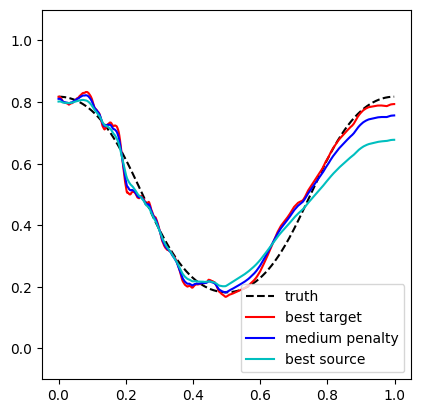

Selected lambdas:
  Best source: 3.94e-04
  Best target: 1.06e-04
  Medium:      1.79e-04


In [4]:
# Select three lambdas to illustrate source vs target optimality
idx_best_source = np.argmin(err_source)
idx_best_target = np.argmin(err_target)
idx_third = (idx_best_source + idx_best_target) // 2

# Deduplicate and ensure three distinct indices
seen = set()
for idx in [idx_best_source, idx_best_target, idx_third]:
    if 0 <= idx < len(lambdas):
        seen.add(idx)
list_idx_three = sorted(seen)
while len(list_idx_three) < 3:
    for c in [0, len(lambdas) // 2, len(lambdas) - 1]:
        if c not in seen and c < len(lambdas):
            seen.add(c)
            list_idx_three = sorted(seen)
            break
    else:
        break
list_idx_three = list_idx_three[:3]

labels = []
for j in list_idx_three:
    if j == idx_best_source and j == idx_best_target:
        labels.append('best (source & target)')
    elif j == idx_best_source:
        labels.append('best source')
    elif j == idx_best_target:
        labels.append('best target')
    elif j == idx_third:
        labels.append('medium penalty')
    else:
        labels.append(f'$\\lambda$={lambdas[j]:.2e}')

X_new = np.arange(0, 1, 0.001)
test.predict_candidates(X_new, list_idx_three)

fig, ax = plt.subplots()
xlim = [-0.05, 1.05]
ylim = [-0.1, 1.1]
plt.ylim(ylim)
plt.xlim(xlim)
# for ground-truth labels: plt.plot(test.X_1, test.y_1, 'k.', alpha=0.3, markersize=5, label='_nolegend_')
plt.plot(X_new, test.mean_new_true, 'k--', label='truth')
colors = ['r', 'b', 'c']
for i, (idx, lbl) in enumerate(zip(list_idx_three, labels)):
    c = colors[i % len(colors)]
    plt.plot(X_new, test.mean_new_candidates[i], f'{c}-', label=lbl)
plt.legend(loc='lower right')
ax.set_aspect((xlim[1] - xlim[0]) / (ylim[1] - ylim[0]))
plt.show()

# Print the penalty values
print('Selected lambdas:')
print(f'  Best source: {lambdas[idx_best_source]:.2e}')
print(f'  Best target: {lambdas[idx_best_target]:.2e}')
print(f'  Medium:      {lambdas[idx_third]:.2e}')

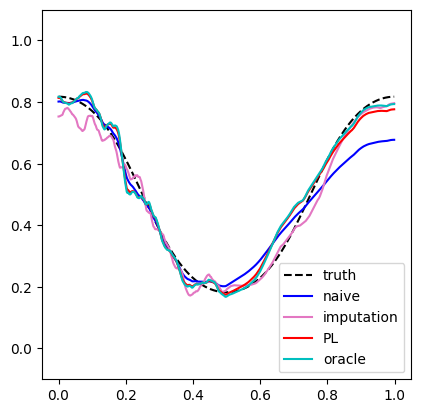

Target excess risks (mean ± ste):
  Naive:   0.0163 (0.0007)
  Pseudo:  0.0035 (0.0008)
  Oracle:  0.0029 (0.0008)

Selected lambdas:
  Naive:  3.94e-04
  Pseudo: 1.38e-04
  Oracle: 1.06e-04


In [5]:
# Pseudo-labeling selection and final comparison
test.evaluate_final(N_test=N_test, seed=seed)
X_new = np.arange(0, 1, 0.001)
test.predict_final(X_new)

fig, ax = plt.subplots()
xlim = [-0.05, 1.05]
ylim = [-0.1, 1.1]
plt.ylim(ylim)
plt.xlim(xlim)
# for ground-truth binary labels: plt.plot(test.X_1, test.y_1, 'k.', alpha=0.3, markersize=5, label='_nolegend_')
plt.plot(X_new, test.mean_new_true, 'k--', label='truth')
plt.plot(X_new, test.mean_new_naive, 'b-', label='naive')
plt.plot(X_new, test.mean_new_tilde, color='tab:pink', label='imputation')
plt.plot(X_new, test.mean_new_pseudo, 'r-', label='PL')
plt.plot(X_new, test.mean_new_real, 'c-', label='oracle')
plt.legend(loc='lower right')
ax.set_aspect((xlim[1] - xlim[0]) / (ylim[1] - ylim[0]))
plt.show()

print('Target excess risks (mean ± ste):')
print(f'  Naive:   {test.err_naive:.4f} ({test.err_naive_ste:.4f})')
print(f'  Pseudo:  {test.err_pseudo:.4f} ({test.err_pseudo_ste:.4f})')
print(f'  Oracle:  {test.err_real:.4f} ({test.err_real_ste:.4f})')
print('\nSelected lambdas:')
print(f'  Naive:  {test.lbd_naive:.2e}')
print(f'  Pseudo: {test.lbd_pseudo:.2e}')
print(f'  Oracle: {test.lbd_real:.2e}')

In [6]:
# Summary table (95% confidence intervals; overlap suggests no significant difference)
z = 1.96  # 95% CI
print('Method        | Target excess risk | 95% CI')
print('-' * 55)
for name, err, ste in [('Naive', test.err_naive, test.err_naive_ste),
                       ('Pseudo-label', test.err_pseudo, test.err_pseudo_ste),
                       ('Oracle', test.err_real, test.err_real_ste)]:
    lo, hi = err - z * ste, err + z * ste
    print(f'{name:14} | {err:.6f}            | [{lo:.6f}, {hi:.6f}]')

Method        | Target excess risk | 95% CI
-------------------------------------------------------
Naive          | 0.016300            | [0.014926, 0.017674]
Pseudo-label   | 0.003481            | [0.001954, 0.005008]
Oracle         | 0.002855            | [0.001312, 0.004399]
